## Imports

In [2]:
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

## Preprocessing

### Downloading the dataset

In [1]:
! kaggle competitions download -c digit-recognizer


  0%|          | 0.00/15.3M [00:00<?, ?B/s]
  7%|▋         | 1.00M/15.3M [00:00<00:01, 7.59MB/s]
 20%|█▉        | 3.00M/15.3M [00:00<00:01, 8.29MB/s]
 33%|███▎      | 5.00M/15.3M [00:00<00:01, 8.88MB/s]
 46%|████▌     | 7.00M/15.3M [00:00<00:00, 9.35MB/s]
 59%|█████▉    | 9.00M/15.3M [00:00<00:00, 9.88MB/s]
 72%|███████▏  | 11.0M/15.3M [00:01<00:00, 10.2MB/s]
 85%|████████▍ | 13.0M/15.3M [00:01<00:00, 10.4MB/s]
 98%|█████████▊| 15.0M/15.3M [00:01<00:00, 10.6MB/s]
100%|██████████| 15.3M/15.3M [00:01<00:00, 10.6MB/s]


### Extracting the dataset

In [3]:
zipref = zipfile.ZipFile('digit-recognizer.zip', 'r')
zipref.extractall()

## Creating the dataset

### Loading Dataset

In [3]:
df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

In [4]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
df.shape, test_df.shape

((42000, 785), (28000, 784))

So, we have 42000 training images and 28000 testing images.

### Extracting labels and images

In [5]:
X = df.iloc[:, 1:].values
y = df.iloc[:,0].values
y = y.reshape(-1, 1)

### Visualizing the dataset

In [6]:
def plot_digit(digit):
    plt.imshow(digit.reshape(28, 28), cmap='gray')
    plt.show()

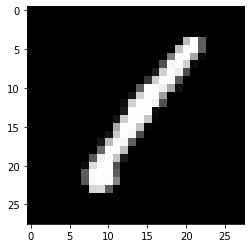

(None, array([1], dtype=int64))

In [7]:
plot_digit(X[0,:]), y[0]

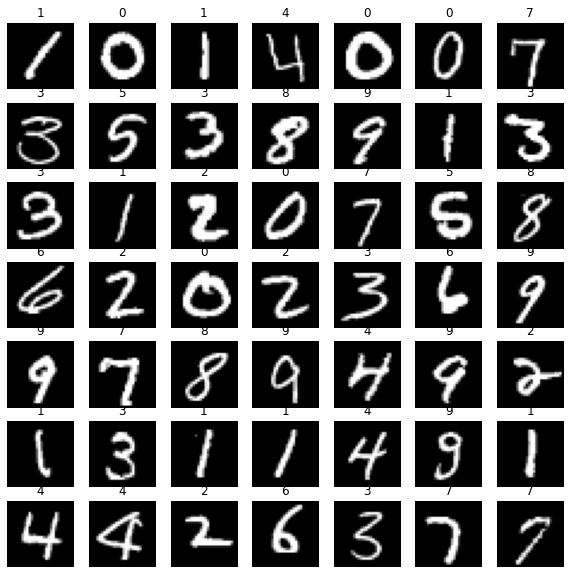

In [8]:
plt.figure(figsize=(10,10))
for i in range(49):
    plt.subplot(7, 7, i+1)
    plt.imshow(X[i,:].reshape(28, 28), cmap='gray')
    plt.title(int(y[i]))
    plt.axis('off')


### Plotting Images class wise

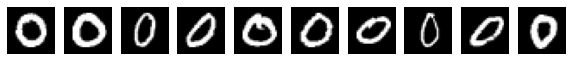

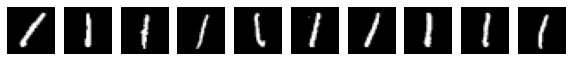

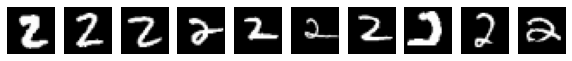

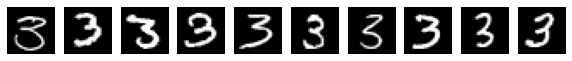

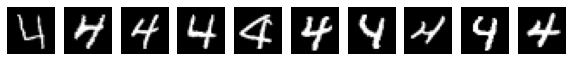

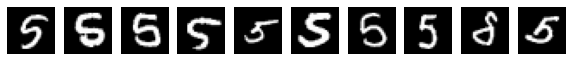

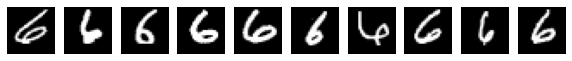

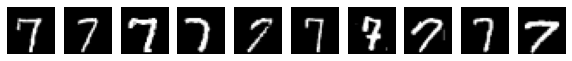

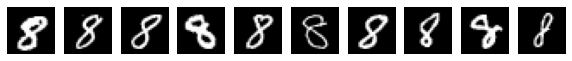

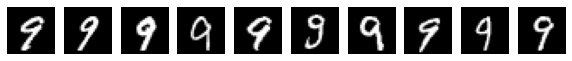

In [9]:
for i in range(10):
    nums = df[df['label'] == i]
    X_num = nums.iloc[:, 1:].values
    plt.figure(figsize=(10,10))
    for j in range(10):
        plt.subplot(1, 10, j+1)
        plt.imshow(X_num[j,:].reshape(28, 28), cmap='gray')
        plt.axis('off')

### Setting train and dev data

In [10]:
len(X)*0.1

4200.0

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

In [7]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((37800, 784), (4200, 784), (37800, 1), (4200, 1))

In [8]:
X_train = X_train/255.
X_test = X_test/255.

In [9]:
y_train = y_train.ravel()
y_test = y_test.ravel()

In [10]:
y_train.shape, y_test.shape

((37800,), (4200,))

## Modeling

### Non-Nueral Networks

In [16]:
from life_saving_tools.Notification import Notification
n = Notification()

In [ ]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(random_state=42, solver='lbfgs', multi_class='ovr', max_iter = 1000)
classifier.fit(X_train, y_train)
n.send_whatsapp_text('Training complete!')

In [18]:
from sklearn.metrics import accuracy_score, confusion_matrix

In [ ]:
classifier.score(X_train, y_train)

0.9315343915343915

In [ ]:
classifier.score(X_test, y_test)

0.9102380952380953

Even the linear classifier is doing great. Let's try XGBOOST.

### XGBOOST

In [ ]:
import xgboost
classifier = xgboost.XGBClassifier(random_state=42)
classifier.fit(X_train, y_train)

C:\Users\harik\anaconda3\lib\site-packages\xgboost\sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)


[16:10:39] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.1/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'multi:softprob' was changed from 'merror' to 'mlogloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=1, enable_categorical=False,
              gamma=0, gpu_id=-1, importance_type=None,
              interaction_constraints='', learning_rate=0.300000012,
              max_delta_step=0, max_depth=6, min_child_weight=1, missing=nan,
              monotone_constraints='()', n_estimators=100, n_jobs=8,
              num_parallel_tree=1, objective='multi:softprob', predictor='auto',
              random_state=42, reg_alpha=0, reg_lambda=1, scale_pos_weight=None,
              subsample=1, tree_method='exact', validate_parameters=1,
              verbosity=None)

In [ ]:
n.play_n_stop()

In [ ]:
accuracy_score(y_test, classifier.predict(X_test))

0.9761904761904762

Okay! About 98% accuracy.

In [70]:
test_data = test_df.values/255.

In [148]:
y_pred = classifier.predict(test_data)

In [67]:
test_data.shape[0] = y_pred.shape[0]

NameError: name 'y_pred' is not defined

In [150]:
y_pred

array([2, 0, 9, ..., 3, 9, 2], dtype=int64)

In [151]:
submission = pd.DataFrame({'ImageId': range(1, 28001), 'Label': y_pred})

In [153]:
submission.to_csv('submission.csv', index=False)

Let's try to improve it.

In [159]:
import warnings
warnings.filterwarnings('ignore')

In [154]:
! kaggle competitions submit -c digit-recognizer -f submission.csv -m "XGBoost Model"

Successfully submitted to Digit Recognizer


  0%|          | 0.00/235k [00:00<?, ?B/s]
  3%|▎         | 8.00k/235k [00:00<00:04, 51.7kB/s]
100%|██████████| 235k/235k [00:04<00:00, 49.3kB/s] 


### Random Forest

In [155]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(n_estimators=300, random_state=42)
rfc.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, random_state=42)

In [156]:
n.play_n_stop()

In [158]:
accuracy_score(y_test, rfc.predict(X_test))

0.9654761904761905

## Neural Networks

We'll start with a simple neural network.

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D

In [64]:
model1 = Sequential()
model1.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
model1.add(MaxPooling2D(pool_size=(2, 2)))
model1.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model1.add(MaxPooling2D(pool_size=(2, 2)))
model1.add(Flatten())
model1.add(Dense(128, activation='relu'))
model1.add(Dense(10, activation='softmax'))

model1.compile(optimizer='adam', loss='sparse_categorical_crossentropy', 
    metrics=['accuracy'])

In [13]:
X_train_n = X_train.reshape(X_train.shape[0], 28, 28, 1)
X_test_n = X_test.reshape(X_test.shape[0], 28, 28, 1)


In [59]:
X_train_n.shape, X_test_n.shape

((37800, 28, 28, 1), (4200, 28, 28, 1))

In [65]:
model1.fit(X_train_n, y_train, epochs=10, validation_data=(X_test_n, y_test))

Epoch 1/10
1182/1182 [==============================] - 35s 26ms/step - loss: 0.1681 - accuracy: 0.9485 - val_loss: 0.0665 - val_accuracy: 0.9781
Epoch 2/10
1182/1182 [==============================] - 34s 29ms/step - loss: 0.0532 - accuracy: 0.9831 - val_loss: 0.0581 - val_accuracy: 0.9817
Epoch 3/10
1182/1182 [==============================] - 33s 28ms/step - loss: 0.0347 - accuracy: 0.9890 - val_loss: 0.0453 - val_accuracy: 0.9857
Epoch 4/10
1182/1182 [==============================] - 31s 26ms/step - loss: 0.0243 - accuracy: 0.9922 - val_loss: 0.0498 - val_accuracy: 0.9843
Epoch 5/10
1182/1182 [==============================] - 30s 26ms/step - loss: 0.0204 - accuracy: 0.9931 - val_loss: 0.0382 - val_accuracy: 0.9886
Epoch 6/10
1182/1182 [==============================] - 29s 24ms/step - loss: 0.0141 - accuracy: 0.9955 - val_loss: 0.0412 - val_accuracy: 0.9886
Epoch 7/10
1182/1182 [==============================] - 32s 27ms/step - loss: 0.0115 - accuracy: 0.9962 - val_loss: 0.0421 -

In [72]:
test_data = test_data.reshape(test_data.shape[0], 28, 28, 1)

In [73]:
def make_submission(model):
    y_pred = model.predict(test_data)
    assert test_data.shape[0] == y_pred.shape[0]
    submission = pd.DataFrame({'ImageId': range(1, test_data.shape[0]+1), 'Label': y_pred})
    return submission

In [66]:
n.play_n_stop()

In [75]:
y_pred = model1.predict(test_data)

In [80]:
y_pred = y_pred.argmax(axis=1)

In [81]:
test_data.shape[0] == y_pred.shape[0]

True

In [82]:
submission = pd.DataFrame({'ImageId': range(1, test_data.shape[0]+1), 'Label': y_pred})

In [86]:
sub = pd.read_csv('submission.csv')
sub.groupby('Label').count()

,ImageId
Label,
0,2759
1,3195
2,2838
3,2765
4,2744
5,2520
6,2746
7,2895
8,2741


In [85]:
submission.groupby('Label').count()

,ImageId
Label,
0,2763
1,3178
2,2814
3,2791
4,2794
5,2532
6,2735
7,2891
8,2735


In [88]:
submission.to_csv('submission2.csv', index=False)

In [90]:
! kaggle competitions submit -c digit-recognizer -f submission2.csv -m "Simple CNN Model"

Successfully submitted to Digit Recognizer


  0%|          | 0.00/235k [00:00<?, ?B/s]
  3%|▎         | 8.00k/235k [00:00<00:04, 52.8kB/s]
100%|██████████| 235k/235k [00:04<00:00, 53.3kB/s] 


### Time to train a final model!

**Goal**: Submit only when error on test set is less than 0.05.

In [108]:
model2 = Sequential()
model2.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1),
                  padding='same')),
model2.add(Conv2D(32, kernel_size=(3, 3), activation='relu',
                    padding='same')),
model2.add(MaxPooling2D(pool_size=(2, 2)))

model2.add(Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'))
model2.add(Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'))
model2.add(MaxPooling2D(pool_size=(2, 2)))

model2.add(Conv2D(128, kernel_size=(3, 3), activation='relu' , padding='same'))
model2.add(Conv2D(128, kernel_size=(3, 3), activation='relu' , padding='same'))
model2.add(MaxPooling2D(pool_size=(2, 2)))

model2.add(Flatten())
model2.add(Dense(128, activation='relu'))
model2.add(Dense(10, activation='softmax'))

model2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', 
    metrics=['accuracy'])

model2.summary()

Model: "sequential_12"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_51 (Conv2D)           (None, 28, 28, 32)        320       
_________________________________________________________________
conv2d_52 (Conv2D)           (None, 28, 28, 32)        9248      
_________________________________________________________________
max_pooling2d_29 (MaxPooling (None, 14, 14, 32)        0         
_________________________________________________________________
conv2d_53 (Conv2D)           (None, 14, 14, 64)        18496     
_________________________________________________________________
conv2d_54 (Conv2D)           (None, 14, 14, 64)        36928     
_________________________________________________________________
max_pooling2d_30 (MaxPooling (None, 7, 7, 64)          0         
_________________________________________________________________
conv2d_55 (Conv2D)           (None, 7, 7, 128)       

In [19]:
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import EarlyStopping
est = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=3)
mch = ModelCheckpoint(
    "models", monitor='val_loss', verbose=1, save_best_only=True,
    save_weights_only=False, mode='auto', save_freq='epoch',
)

In [109]:
history_2 = model2.fit(X_train_n, y_train, epochs=25, validation_data=(X_test_n, y_test),
    callbacks=[est, mch])

Epoch 1/25
1182/1182 [==============================] - 174s 144ms/step - loss: 0.1513 - accuracy: 0.9535 - val_loss: 0.0507 - val_accuracy: 0.9840

Epoch 00001: val_loss improved from inf to 0.05071, saving model to models
INFO:tensorflow:Assets written to: models\assets
Epoch 2/25
1182/1182 [==============================] - 208s 176ms/step - loss: 0.0474 - accuracy: 0.9857 - val_loss: 0.0564 - val_accuracy: 0.9857

Epoch 00002: val_loss did not improve from 0.05071
Epoch 3/25
1182/1182 [==============================] - 180s 152ms/step - loss: 0.0362 - accuracy: 0.9889 - val_loss: 0.0480 - val_accuracy: 0.9850

Epoch 00003: val_loss improved from 0.05071 to 0.04803, saving model to models
INFO:tensorflow:Assets written to: models\assets
Epoch 4/25
1182/1182 [==============================] - 177s 150ms/step - loss: 0.0289 - accuracy: 0.9917 - val_loss: 0.0475 - val_accuracy: 0.9850

Epoch 00004: val_loss improved from 0.04803 to 0.04754, saving model to models
INFO:tensorflow:Assets

In [110]:
n.send_whatsapp_text(f'Training complete')

SM15bd9bd91c9144729d3ca221a80baa16


In [115]:
model = tf.keras.models.load_model('models')

In [116]:
model.summary()

Model: "sequential_12"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_51 (Conv2D)           (None, 28, 28, 32)        320       
_________________________________________________________________
conv2d_52 (Conv2D)           (None, 28, 28, 32)        9248      
_________________________________________________________________
max_pooling2d_29 (MaxPooling (None, 14, 14, 32)        0         
_________________________________________________________________
conv2d_53 (Conv2D)           (None, 14, 14, 64)        18496     
_________________________________________________________________
conv2d_54 (Conv2D)           (None, 14, 14, 64)        36928     
_________________________________________________________________
max_pooling2d_30 (MaxPooling (None, 7, 7, 64)          0         
_________________________________________________________________
conv2d_55 (Conv2D)           (None, 7, 7, 128)       

In [14]:
model = tf.keras.models.load_model("models")
model.evaluate(X_test_n, y_test)

132/132 [==============================] - 13s 43ms/step - loss: 0.0377 - accuracy: 0.9910


[0.0376964807510376, 0.9909523725509644]

In [15]:
from tensorflow.keras.layers import AveragePooling2D, BatchNormalization, Dropout, Flatten, Dense

In [18]:
model2 = Sequential()
model2.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1),
               padding='same')),
model2.add(Conv2D(32, kernel_size=(3, 3), activation='relu',
                  padding='same')),
model2.add(AveragePooling2D(pool_size=(2, 2)))
model2.add(BatchNormalization())
model2.add(Dropout(0.2))

model2.add(Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'))
model2.add(Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'))
model2.add(AveragePooling2D(pool_size=(2, 2)))
model2.add(BatchNormalization())

model2.add(Dropout(0.3))
model2.add(Conv2D(128, kernel_size=(3, 3), activation='relu' , padding='same'))
model2.add(Conv2D(128, kernel_size=(3, 3), activation='relu' , padding='same'))
model2.add(AveragePooling2D(pool_size=(2, 2)))
model2.add(BatchNormalization())

model2.add(Flatten())
model2.add(Dropout(0.3))
model2.add(Dense(128, activation='relu'))
model2.add(Dense(10, activation='softmax'))

model2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', 
    metrics=['accuracy'])

model2.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 28, 28, 32)        320       
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 28, 28, 32)        9248      
_________________________________________________________________
average_pooling2d (AveragePo (None, 14, 14, 32)        0         
_________________________________________________________________
batch_normalization (BatchNo (None, 14, 14, 32)        128       
_________________________________________________________________
dropout (Dropout)            (None, 14, 14, 32)        0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 14, 14, 64)        18496     
_________________________________________________________________
conv2d_3 (Conv2D)            (None, 14, 14, 64)        3

In [20]:
history_4 = model2.fit(X_train, y_train, epochs=100, validation_data=(X_test, y_test),
        callbacks=[mch])

Epoch 1/100


ValueError: in user code:

    C:\Users\harik\anaconda3\envs\data_sciences\lib\site-packages\tensorflow\python\keras\engine\training.py:855 train_function  *
        return step_function(self, iterator)
    C:\Users\harik\anaconda3\envs\data_sciences\lib\site-packages\tensorflow\python\keras\engine\training.py:845 step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    C:\Users\harik\anaconda3\envs\data_sciences\lib\site-packages\tensorflow\python\distribute\distribute_lib.py:1285 run
        return self._extended.call_for_each_replica(fn, args=args, kwargs=kwargs)
    C:\Users\harik\anaconda3\envs\data_sciences\lib\site-packages\tensorflow\python\distribute\distribute_lib.py:2833 call_for_each_replica
        return self._call_for_each_replica(fn, args, kwargs)
    C:\Users\harik\anaconda3\envs\data_sciences\lib\site-packages\tensorflow\python\distribute\distribute_lib.py:3608 _call_for_each_replica
        return fn(*args, **kwargs)
    C:\Users\